# Telemetry Noise Analysis Across Database Backends
## Databend vs Firebolt on TPC-H SF20 and TPC-DS SF20

**Research questions:**
1. How noisy are telemetry estimates (CPU time, data scanned) across different backends?
2. For which queries is there more noise?
3. Could there be 1:N matching? Are there semantically different queries with very similar telemetry?

**How CPU time is collected:**
- Databend: process CPU-seconds from Prometheus counter delta (per-query, since benchmarks run one query at a time)
- Firebolt: per-query CPU milliseconds from `engine_query_history`

Both are per-query CPU measurements but at different scales (OS-level vs engine-reported), so the diagonal on the CPU scatter shows where magnitudes would match.

**Filtering:** Failed queries are discarded, there were a few in tpc-ds firebolt.

In [73]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import adjusted_rand_score
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

DATA_DIR = Path('./metrics_witho/output')

In [74]:
def load_metrics(filepath):
    with open(filepath) as f:
        return json.load(f)

tpch_db = load_metrics(DATA_DIR / 'TPCH-tpch20g-sql-metrics.json')
tpch_fb = load_metrics(DATA_DIR / 'TPCH-tpch20g-sql-metrics-firebolt.json')
tpcds_db = load_metrics(DATA_DIR / 'tpcds_all-tpcds20g-sql-metrics.json')
tpcds_fb = load_metrics(DATA_DIR / 'tpcds_all-tpcds20g-sql-metrics-firebolt.json')

print(f'TPC-H:  Databend={len(tpch_db)}, Firebolt={len(tpch_fb)}')
print(f'TPC-DS: Databend={len(tpcds_db)}, Firebolt={len(tpcds_fb)}')

TPC-H:  Databend=22, Firebolt=22
TPC-DS: Databend=99, Firebolt=99


## 0. Data Preparation


In [75]:
def build_tpch_df(db_data, fb_data):
    rows = []
    for i in range(min(len(db_data), len(fb_data))):
        d, f = db_data[i], fb_data[i]
        rows.append({
            'query': f'Q{i+1}',
            'db_cpu_s': d['avg_cpu_time'],
            'db_scan_bytes': d['avg_scan_bytes'],
            'db_duration_s': d['avg_duration'],
            'db_filter': d.get('filter', np.nan),
            'db_join': d.get('join', np.nan),
            'db_agg': d.get('agg', np.nan),
            'db_sort': d.get('sort', np.nan),
            'fb_cpu_s': f['avg_cpu_time'] / 1000.0,
            'fb_scan_bytes': f['avg_scan_bytes'],
            'fb_duration_s': f['avg_duration'],
            'fb_filter': f.get('filter', np.nan),
            'fb_join': f.get('join', np.nan),
            'fb_agg': f.get('agg', np.nan),
            'fb_sort': f.get('sort', np.nan),
        })
    df = pd.DataFrame(rows).set_index('query')
    return df

def build_tpcds_df(db_data, fb_data):
    rows = []
    for i in range(min(len(db_data), len(fb_data))):
        d, f = db_data[i], fb_data[i]
        rows.append({
            'query': f'Q{i+1}',
            'db_cpu_s': d.get('avg_cpu_time', 0),
            'db_scan_bytes': d.get('avg_scan_bytes', 0),
            'db_duration_s': d.get('avg_duration', 0),
            'db_filter': d.get('filter', np.nan),
            'db_join': d.get('join', np.nan),
            'db_agg': d.get('agg', np.nan),
            'db_sort': d.get('sort', np.nan),
            'fb_cpu_s': f.get('avg_cpu_time', 0) / 1000.0,
            'fb_scan_bytes': f.get('avg_scan_bytes', 0),
            'fb_duration_s': f.get('avg_duration', 0),
            'fb_filter': f.get('filter', np.nan),
            'fb_join': f.get('join', np.nan),
            'fb_agg': f.get('agg', np.nan),
            'fb_sort': f.get('sort', np.nan),
        })
    df = pd.DataFrame(rows).set_index('query')
    return df

tpch_raw = build_tpch_df(tpch_db, tpch_fb)
tpcds_raw = build_tpcds_df(tpcds_db, tpcds_fb)

# Filter: discard queries where EITHER backend has scan_bytes == 0
tpch = tpch_raw[(tpch_raw['db_scan_bytes'] > 0) & (tpch_raw['fb_scan_bytes'] > 0)].copy()
tpcds = tpcds_raw[(tpcds_raw['db_scan_bytes'] > 0) & (tpcds_raw['fb_scan_bytes'] > 0)].copy()

print(f'TPC-H:  {len(tpch_raw)} raw -> {len(tpch)} after filtering (dropped {len(tpch_raw)-len(tpch)})')
print(f'TPC-DS: {len(tpcds_raw)} raw -> {len(tpcds)} after filtering (dropped {len(tpcds_raw)-len(tpcds)})')

# Show which TPC-DS queries were dropped
dropped = tpcds_raw.index[~tpcds_raw.index.isin(tpcds.index)].tolist()
if dropped:
    print(f'Dropped TPC-DS queries: {dropped}')

TPC-H:  22 raw -> 22 after filtering (dropped 0)
TPC-DS: 99 raw -> 88 after filtering (dropped 11)
Dropped TPC-DS queries: ['Q6', 'Q8', 'Q9', 'Q29', 'Q32', 'Q33', 'Q58', 'Q78', 'Q84', 'Q86', 'Q92']


In [76]:
# Compute within-backend ranks
EPS = 1e-9

for df in [tpch, tpcds]:
    for metric in ['duration_s', 'scan_bytes', 'cpu_s']:
        df[f'db_{metric}_rank'] = df[f'db_{metric}'].rank()
        df[f'fb_{metric}_rank'] = df[f'fb_{metric}'].rank()
    # Log-ratios (Firebolt / Databend)
    df['log2_scan_ratio'] = np.log2((df['fb_scan_bytes'] + EPS) / (df['db_scan_bytes'] + EPS))
    df['log2_duration_ratio'] = np.log2((df['fb_duration_s'] + EPS) / (df['db_duration_s'] + EPS))

print(f'TPC-H:  {len(tpch)} queries with ranks computed')
print(f'TPC-DS: {len(tpcds)} queries with ranks computed')

TPC-H:  22 queries with ranks computed
TPC-DS: 88 queries with ranks computed


---
## 1. RQ1: How Noisy Are Telemetry Estimates Across Backends?

Since CPU time semantics differ fundamentally, we focus on:
- **Rank correlation** (Spearman): do backends agree on the *ordering* of query expense?
- **Duration scatter** (log-log): the most directly comparable metric
- **Log-ratio distributions**: how much do estimates diverge per query?

A Spearman rho close to 1.0 means the backends rank queries in roughly the same order (strong agreement); below 0.5 suggests the ordering is substantially different. 

In the duration scatter, points near the diagonal mean both backends take similar time; points far below the diagonal mean Firebolt is faster. 

In the log-ratio histograms, a distribution centered at 0 means no systematic bias; a wide spread means high per-query noise.

In [77]:
def rank_correlations(df, metrics, label):
    results = []
    for m in metrics:
        rho, p = stats.spearmanr(df[f'db_{m}'], df[f'fb_{m}'])
        results.append({'metric': m, 'spearman_rho': round(rho, 3), 'p_value': round(p, 4)})
    res = pd.DataFrame(results)
    print(f'\n{label} — Spearman Rank Correlations:')
    display(res)
    return res

tpch_corr = rank_correlations(tpch, ['duration_s', 'scan_bytes', 'cpu_s'], f'TPC-H (n={len(tpch)})')
tpcds_corr = rank_correlations(tpcds, ['duration_s', 'scan_bytes', 'cpu_s'], f'TPC-DS (n={len(tpcds)})')


TPC-H (n=22) — Spearman Rank Correlations:


,metric,spearman_rho,p_value
0,duration_s,0.720,0.0002
1,scan_bytes,0.188,0.4020
2,cpu_s,0.677,0.0005



TPC-DS (n=88) — Spearman Rank Correlations:


,metric,spearman_rho,p_value
0,duration_s,0.765,0.0
1,scan_bytes,0.456,0.0
2,cpu_s,0.779,0.0


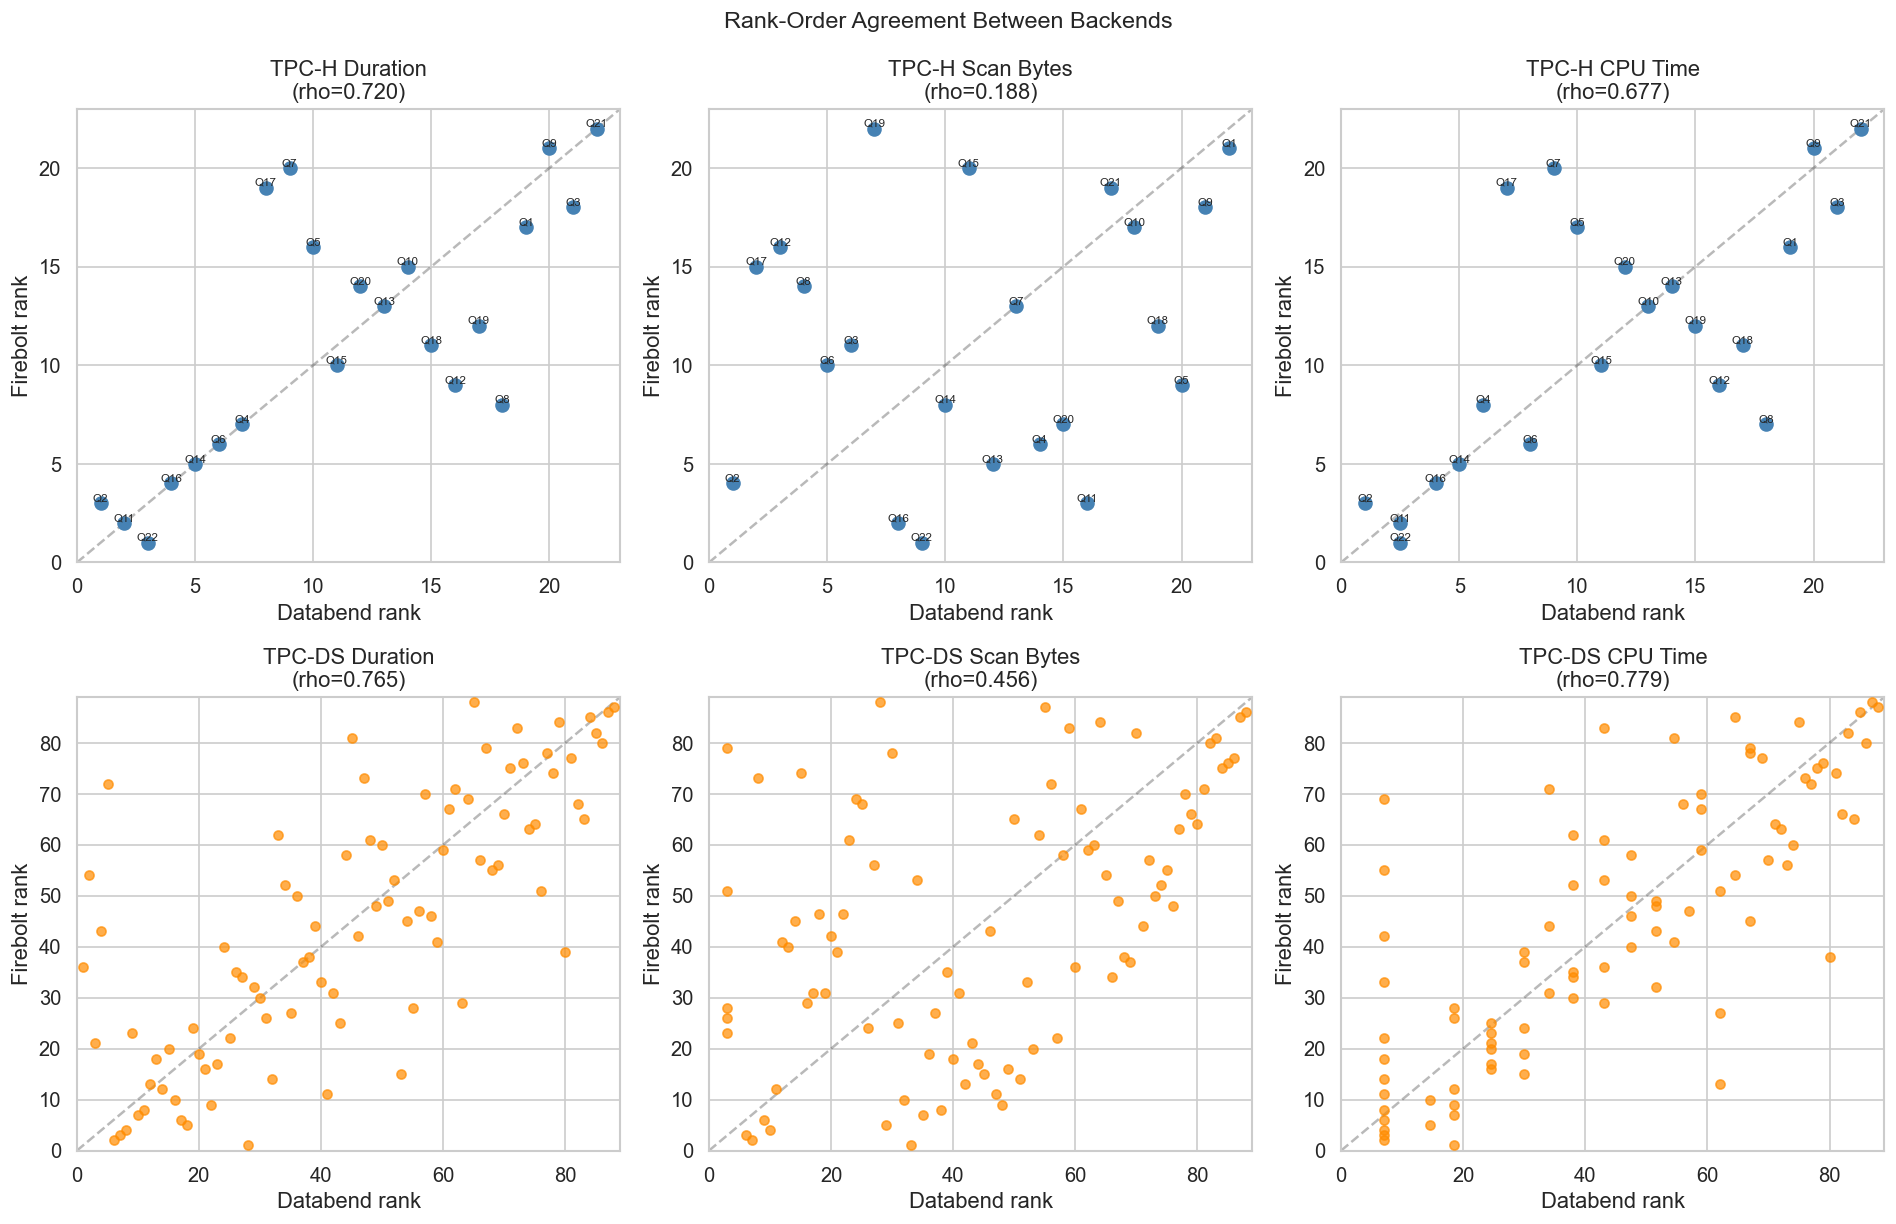

In [78]:
# Rank-rank scatter plots (2x3 grid)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
metric_labels = {'duration_s': 'Duration', 'scan_bytes': 'Scan Bytes', 'cpu_s': 'CPU Time'}

for col, metric in enumerate(['duration_s', 'scan_bytes', 'cpu_s']):
    # TPC-H
    ax = axes[0, col]
    ax.scatter(tpch[f'db_{metric}_rank'], tpch[f'fb_{metric}_rank'],
               c='steelblue', s=60, zorder=3)
    for idx, row in tpch.iterrows():
        ax.annotate(idx, (row[f'db_{metric}_rank'], row[f'fb_{metric}_rank']),
                    fontsize=7, ha='center', va='bottom')
    lim = [0, len(tpch) + 1]
    ax.plot(lim, lim, 'k--', alpha=0.3)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel('Databend rank')
    ax.set_ylabel('Firebolt rank')
    rho = tpch_corr[tpch_corr.metric == metric].spearman_rho.values[0]
    ax.set_title(f'TPC-H {metric_labels[metric]}\n(rho={rho:.3f})')

    # TPC-DS
    ax = axes[1, col]
    ax.scatter(tpcds[f'db_{metric}_rank'], tpcds[f'fb_{metric}_rank'],
               c='darkorange', s=30, alpha=0.7, zorder=3)
    lim = [0, len(tpcds) + 1]
    ax.plot(lim, lim, 'k--', alpha=0.3)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel('Databend rank')
    ax.set_ylabel('Firebolt rank')
    rho = tpcds_corr[tpcds_corr.metric == metric].spearman_rho.values[0]
    ax.set_title(f'TPC-DS {metric_labels[metric]}\n(rho={rho:.3f})')

plt.tight_layout()
fig.suptitle('Rank-Order Agreement Between Backends', y=1.02, fontsize=14)
plt.show()

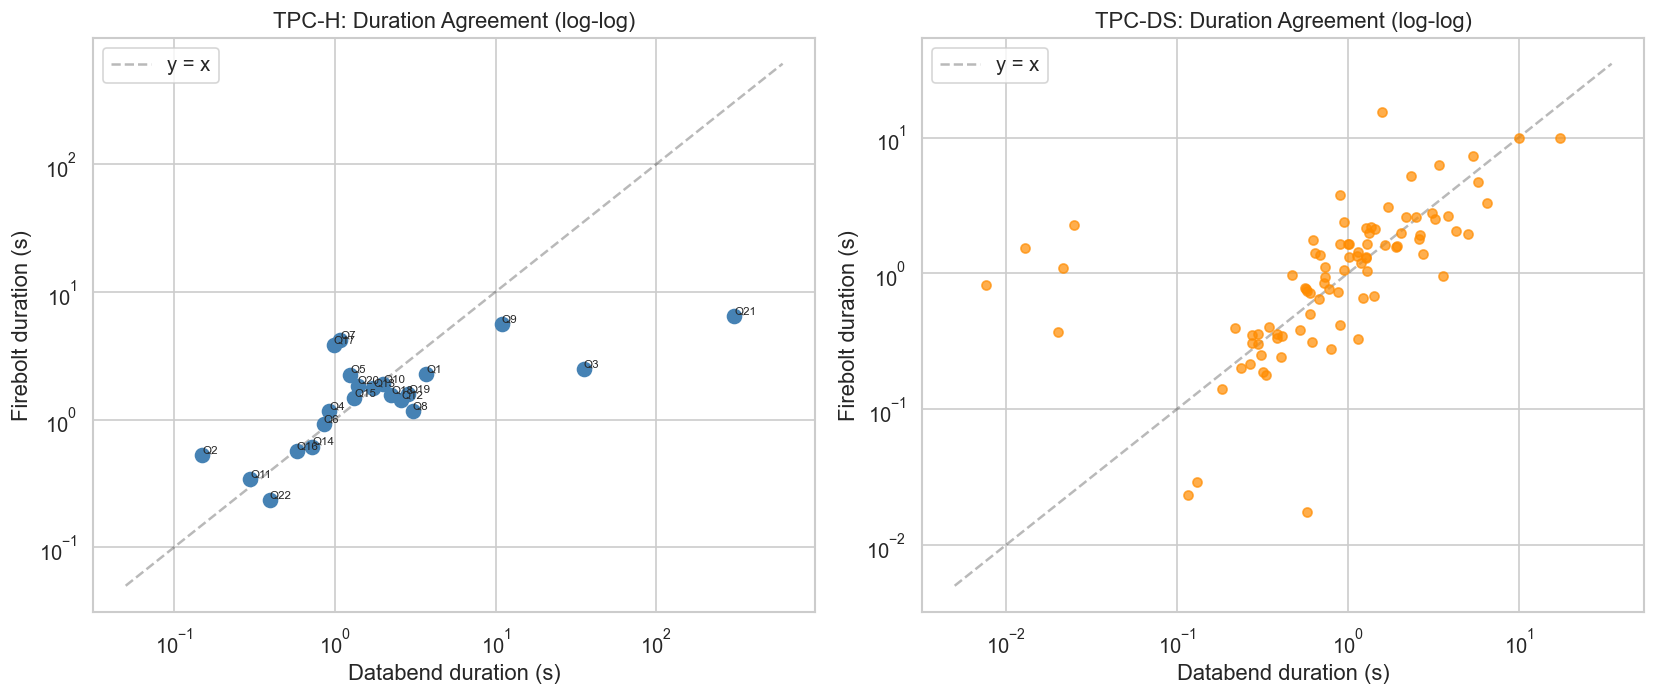

In [79]:
# Duration scatter (actual values, log-log)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# TPC-H
ax1.scatter(tpch['db_duration_s'], tpch['fb_duration_s'], c='steelblue', s=70, zorder=3)
for idx, row in tpch.iterrows():
    ax1.annotate(idx, (row['db_duration_s'], row['fb_duration_s']),
                fontsize=7, ha='left', va='bottom')
lim = [0.05, max(tpch['db_duration_s'].max(), tpch['fb_duration_s'].max()) * 2]
ax1.plot(lim, lim, 'k--', alpha=0.3, label='y = x')
ax1.set_xscale('log'); ax1.set_yscale('log')
ax1.set_xlabel('Databend duration (s)'); ax1.set_ylabel('Firebolt duration (s)')
ax1.set_title('TPC-H: Duration Agreement (log-log)')
ax1.legend()

# TPC-DS
ax2.scatter(tpcds['db_duration_s'], tpcds['fb_duration_s'],
           c='darkorange', s=30, alpha=0.7, zorder=3)
lim = [0.005, max(tpcds['db_duration_s'].max(), tpcds['fb_duration_s'].max()) * 2]
ax2.plot(lim, lim, 'k--', alpha=0.3, label='y = x')
ax2.set_xscale('log'); ax2.set_yscale('log')
ax2.set_xlabel('Databend duration (s)'); ax2.set_ylabel('Firebolt duration (s)')
ax2.set_title('TPC-DS: Duration Agreement (log-log)')
ax2.legend()

plt.tight_layout()
plt.show()

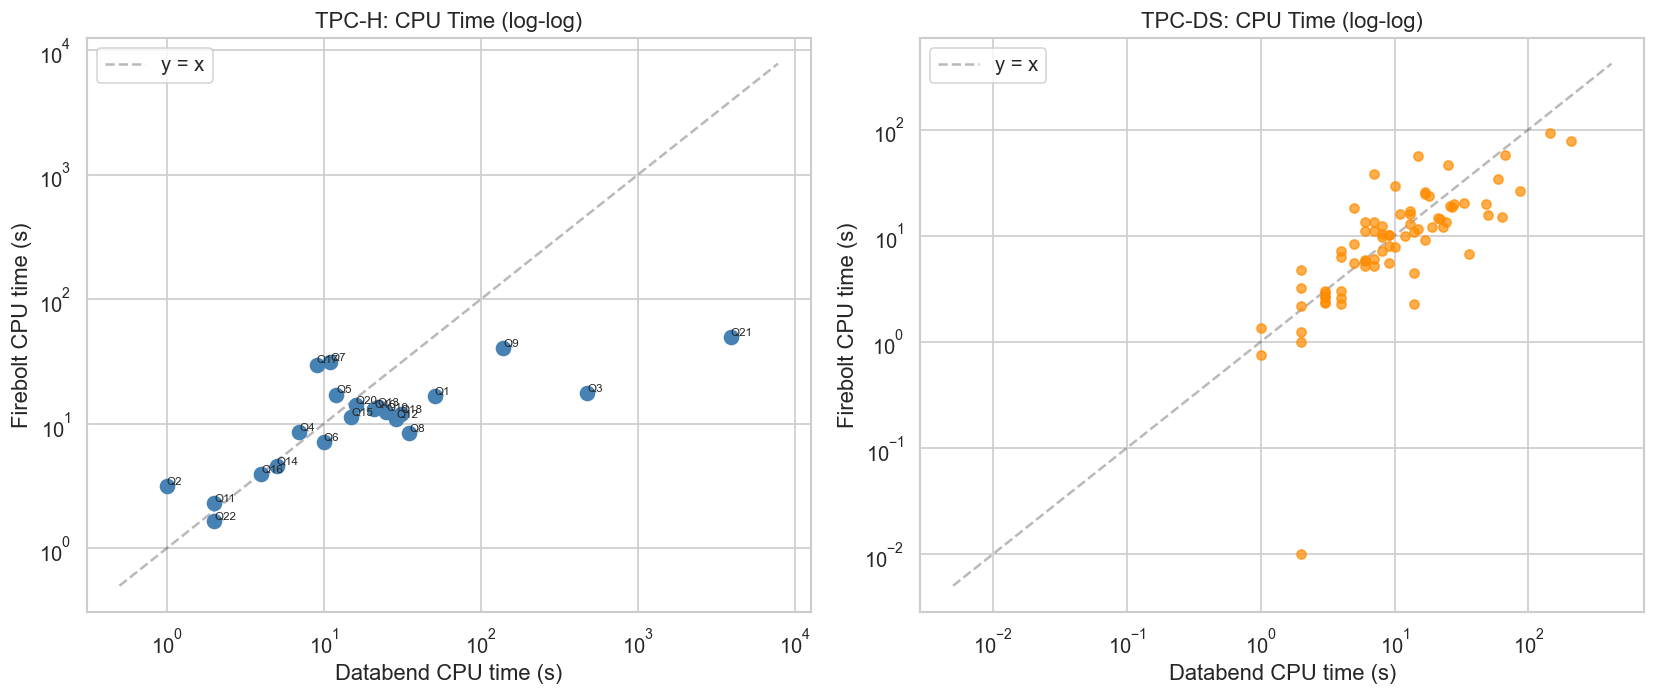

In [80]:
# CPU time scatter (actual values, log-log)
# Benchmarks run 1 query at a time, so Databend Prometheus delta is effectively per-query.
# Units still differ (Databend=OS CPU-seconds, Firebolt=engine CPU-ms converted to s).
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# TPC-H
ax1.scatter(tpch['db_cpu_s'], tpch['fb_cpu_s'], c='steelblue', s=70, zorder=3)
for idx, row in tpch.iterrows():
    ax1.annotate(idx, (row['db_cpu_s'], row['fb_cpu_s']),
                fontsize=7, ha='left', va='bottom')
lim = [min(tpch['db_cpu_s'].min(), tpch['fb_cpu_s'].min()) * 0.5,
       max(tpch['db_cpu_s'].max(), tpch['fb_cpu_s'].max()) * 2]
ax1.plot(lim, lim, 'k--', alpha=0.3, label='y = x')
ax1.set_xscale('log'); ax1.set_yscale('log')
ax1.set_xlabel('Databend CPU time (s)'); ax1.set_ylabel('Firebolt CPU time (s)')
ax1.set_title('TPC-H: CPU Time (log-log)')
ax1.legend()

# TPC-DS
valid_cpu = tpcds[(tpcds['db_cpu_s'] > 0) & (tpcds['fb_cpu_s'] > 0)]
ax2.scatter(valid_cpu['db_cpu_s'], valid_cpu['fb_cpu_s'],
           c='darkorange', s=30, alpha=0.7, zorder=3)
lim = [min(valid_cpu['db_cpu_s'].min(), valid_cpu['fb_cpu_s'].min()) * 0.5,
       max(valid_cpu['db_cpu_s'].max(), valid_cpu['fb_cpu_s'].max()) * 2]
ax2.plot(lim, lim, 'k--', alpha=0.3, label='y = x')
ax2.set_xscale('log'); ax2.set_yscale('log')
ax2.set_xlabel('Databend CPU time (s)'); ax2.set_ylabel('Firebolt CPU time (s)')
ax2.set_title('TPC-DS: CPU Time (log-log)')
ax2.legend()

plt.tight_layout()
plt.show()

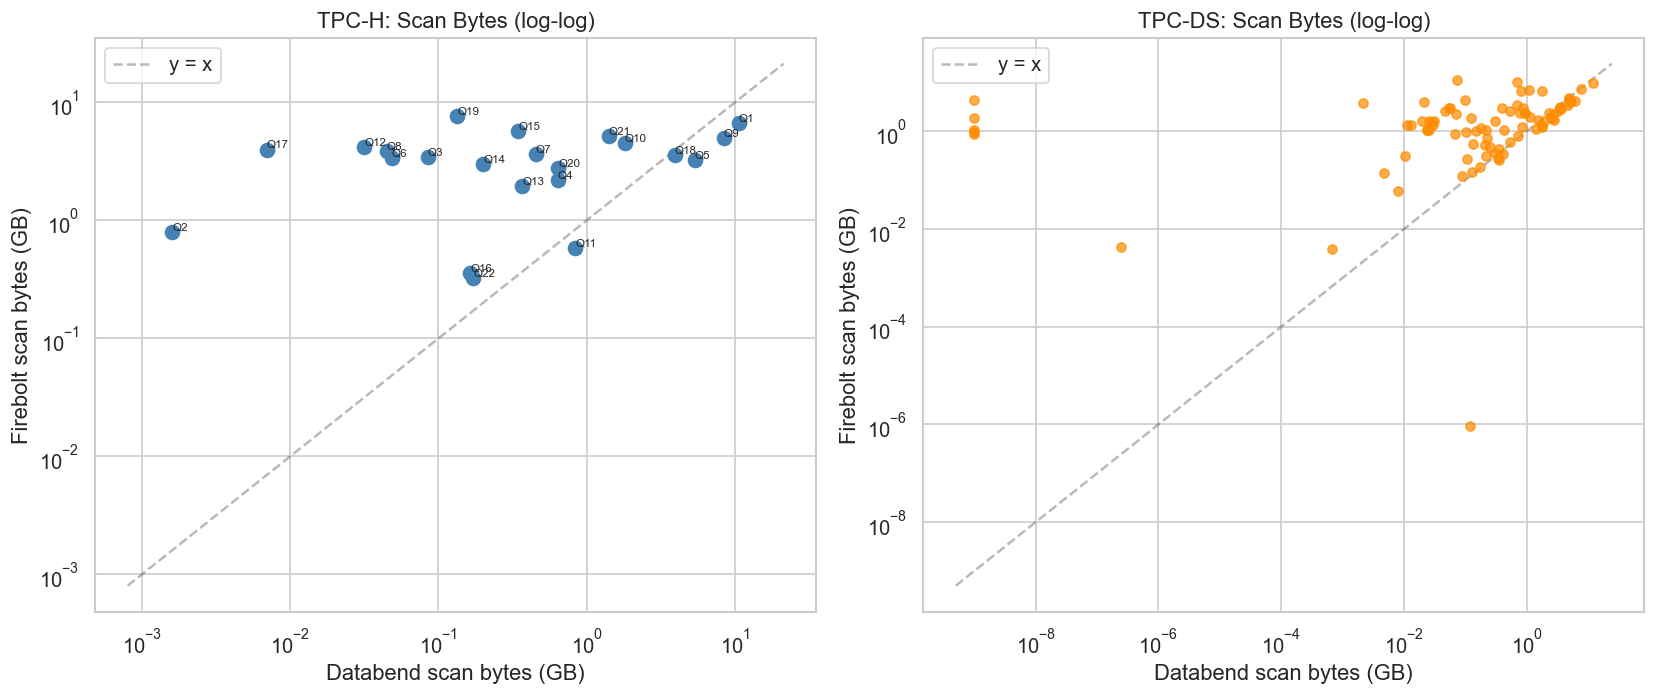

In [81]:
# Scan bytes scatter (actual values, log-log) — Databend vs Firebolt
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# TPC-H
ax1.scatter(tpch['db_scan_bytes'] / 1e9, tpch['fb_scan_bytes'] / 1e9,
           c='steelblue', s=70, zorder=3)
for idx, row in tpch.iterrows():
    ax1.annotate(idx, (row['db_scan_bytes'] / 1e9, row['fb_scan_bytes'] / 1e9),
                fontsize=7, ha='left', va='bottom')
lim = [min(tpch['db_scan_bytes'].min(), tpch['fb_scan_bytes'].min()) / 1e9 * 0.5,
       max(tpch['db_scan_bytes'].max(), tpch['fb_scan_bytes'].max()) / 1e9 * 2]
ax1.plot(lim, lim, 'k--', alpha=0.3, label='y = x')
ax1.set_xscale('log'); ax1.set_yscale('log')
ax1.set_xlabel('Databend scan bytes (GB)'); ax1.set_ylabel('Firebolt scan bytes (GB)')
ax1.set_title('TPC-H: Scan Bytes (log-log)')
ax1.legend()

# TPC-DS
valid_scan = tpcds[(tpcds['db_scan_bytes'] > 0) & (tpcds['fb_scan_bytes'] > 0)]
ax2.scatter(valid_scan['db_scan_bytes'] / 1e9, valid_scan['fb_scan_bytes'] / 1e9,
           c='darkorange', s=30, alpha=0.7, zorder=3)
lim = [min(valid_scan['db_scan_bytes'].min(), valid_scan['fb_scan_bytes'].min()) / 1e9 * 0.5,
       max(valid_scan['db_scan_bytes'].max(), valid_scan['fb_scan_bytes'].max()) / 1e9 * 2]
ax2.plot(lim, lim, 'k--', alpha=0.3, label='y = x')
ax2.set_xscale('log'); ax2.set_yscale('log')
ax2.set_xlabel('Databend scan bytes (GB)'); ax2.set_ylabel('Firebolt scan bytes (GB)')
ax2.set_title('TPC-DS: Scan Bytes (log-log)')
ax2.legend()

plt.tight_layout()
plt.show()

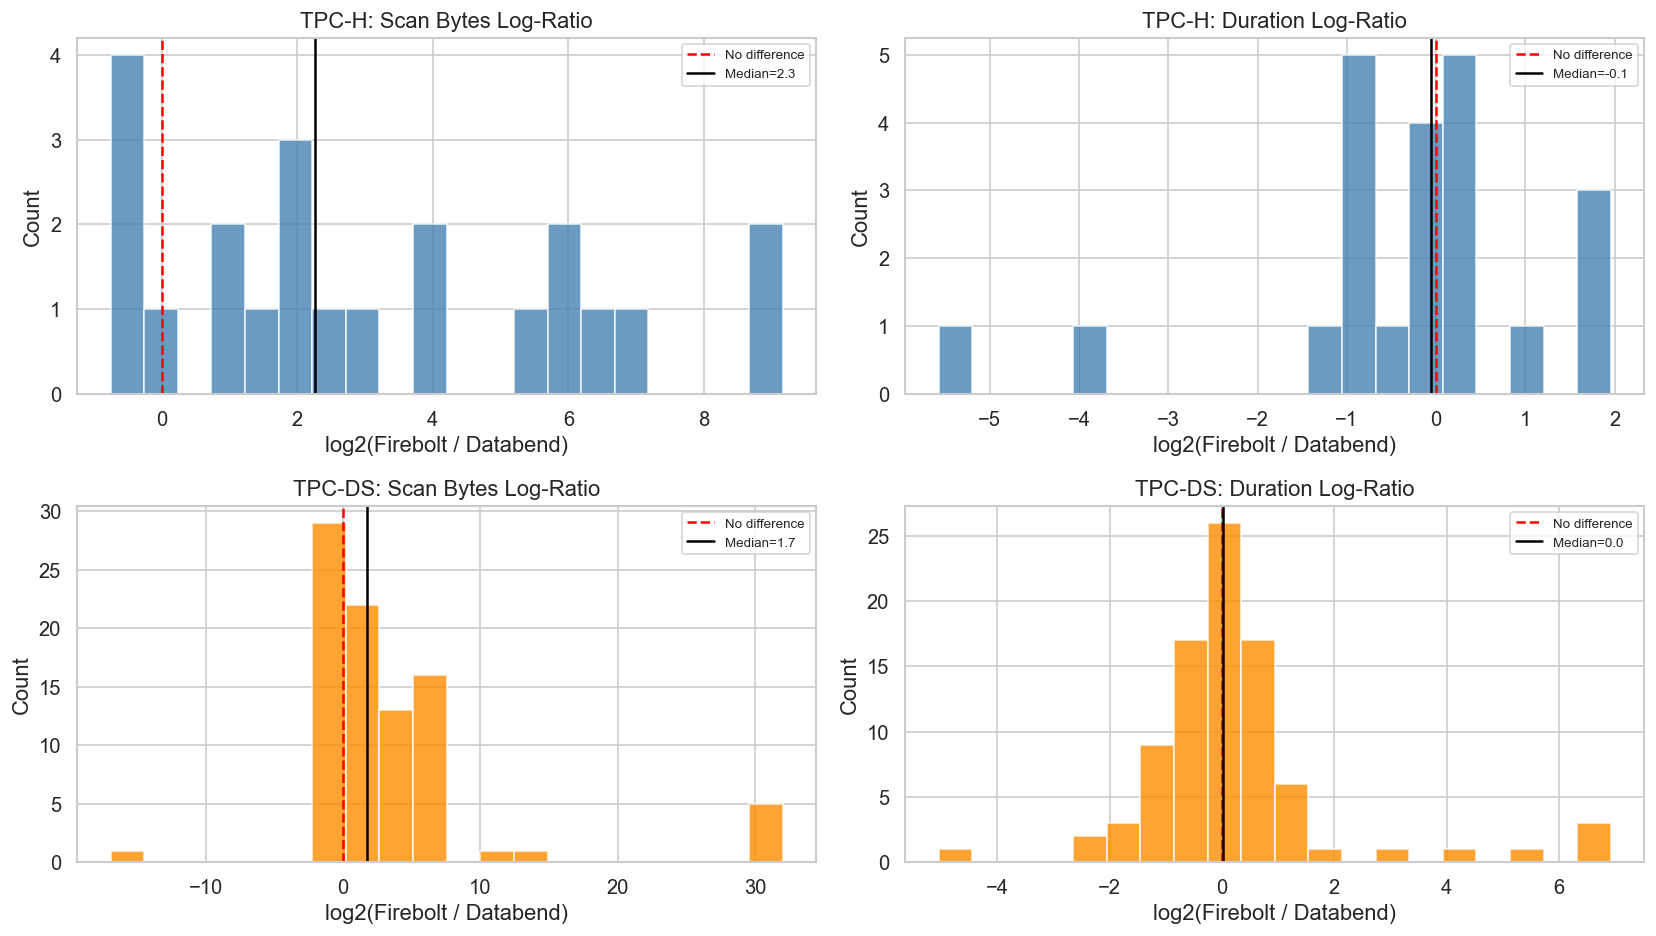

In [82]:
# Log-ratio distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for row_idx, (df, label, color) in enumerate([(tpch, 'TPC-H', 'steelblue'),
                                               (tpcds, 'TPC-DS', 'darkorange')]):
    for col_idx, metric in enumerate(['log2_scan_ratio', 'log2_duration_ratio']):
        ax = axes[row_idx, col_idx]
        data = df[metric].replace([np.inf, -np.inf], np.nan).dropna()
        ax.hist(data, bins=20, color=color, edgecolor='white', alpha=0.8)
        ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='No difference')
        ax.axvline(data.median(), color='black', linestyle='-', linewidth=1.5,
                  label=f'Median={data.median():.1f}')
        metric_name = 'Scan Bytes' if 'scan' in metric else 'Duration'
        ax.set_xlabel('log2(Firebolt / Databend)')
        ax.set_ylabel('Count')
        ax.set_title(f'{label}: {metric_name} Log-Ratio')
        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

**How to read these histograms:**

Each bar counts how many queries fall at a given log2 ratio of Firebolt / Databend.

- **x = 0** (red dashed line): the two backends report the same value. 
- **x = 1**: Firebolt's value is 2× Databend's. **x = −1**: Databend's is 2× Firebolt's.
- **x = 5**: Firebolt reports 32× more. **x = −5**: Databend reports 32× more.

A **narrow distribution centered near 0** means the backends largely agree.  
A **wide or shifted distribution** means systematic disagreement.

Here, scan bytes are shifted far positive (median ~4–5), meaning Firebolt consistently reports much more data scanned than Databend.

In [83]:
# Summary statistics
def compute_agreement_stats(df, label):
    dur_rho, _ = stats.spearmanr(df['db_duration_s'], df['fb_duration_s'])
    scan_rho, _ = stats.spearmanr(df['db_scan_bytes'], df['fb_scan_bytes'])
    cpu_rho, _ = stats.spearmanr(df['db_cpu_s'], df['fb_cpu_s'])

    dur_ratios = np.maximum(df['db_duration_s'], df['fb_duration_s']) / (
        np.minimum(df['db_duration_s'], df['fb_duration_s']) + EPS)
    scan_ratios = np.maximum(df['db_scan_bytes'], df['fb_scan_bytes']) / (
        np.minimum(df['db_scan_bytes'], df['fb_scan_bytes']) + EPS)

    return {
        'benchmark': label,
        'n_queries': len(df),
        'duration_rho': round(dur_rho, 3),
        'scan_rho': round(scan_rho, 3),
        'cpu_rho': round(cpu_rho, 3),
        'duration_ratio_median': round(dur_ratios.median(), 1),
        'duration_ratio_max': round(dur_ratios.max(), 1),
        'scan_ratio_median': round(scan_ratios.median(), 1),
        'scan_ratio_max': round(scan_ratios.max(), 1),
    }

summary = pd.DataFrame([
    compute_agreement_stats(tpch, 'TPC-H'),
    compute_agreement_stats(tpcds, 'TPC-DS')
])
display(summary)

,benchmark,n_queries,duration_rho,scan_rho,cpu_rho,duration_ratio_median,duration_ratio_max,scan_ratio_median,scan_ratio_max
0,TPC-H,22,0.720,0.188,0.677,1.7,47.5,4.8,5.734000e+02
1,TPC-DS,88,0.765,0.456,0.779,1.4,121.0,3.6,4.295054e+09


---
## 2. RQ2: Which Queries Show the Most Disagreement?

Per-query "noise" measured two ways across all three metrics (duration, CPU time, scan bytes):
- **Rank displacement**: how far apart a query's rank is between Databend and Firebolt
- **Value ratio**: max(backend_A, backend_B) / min(backend_A, backend_B)

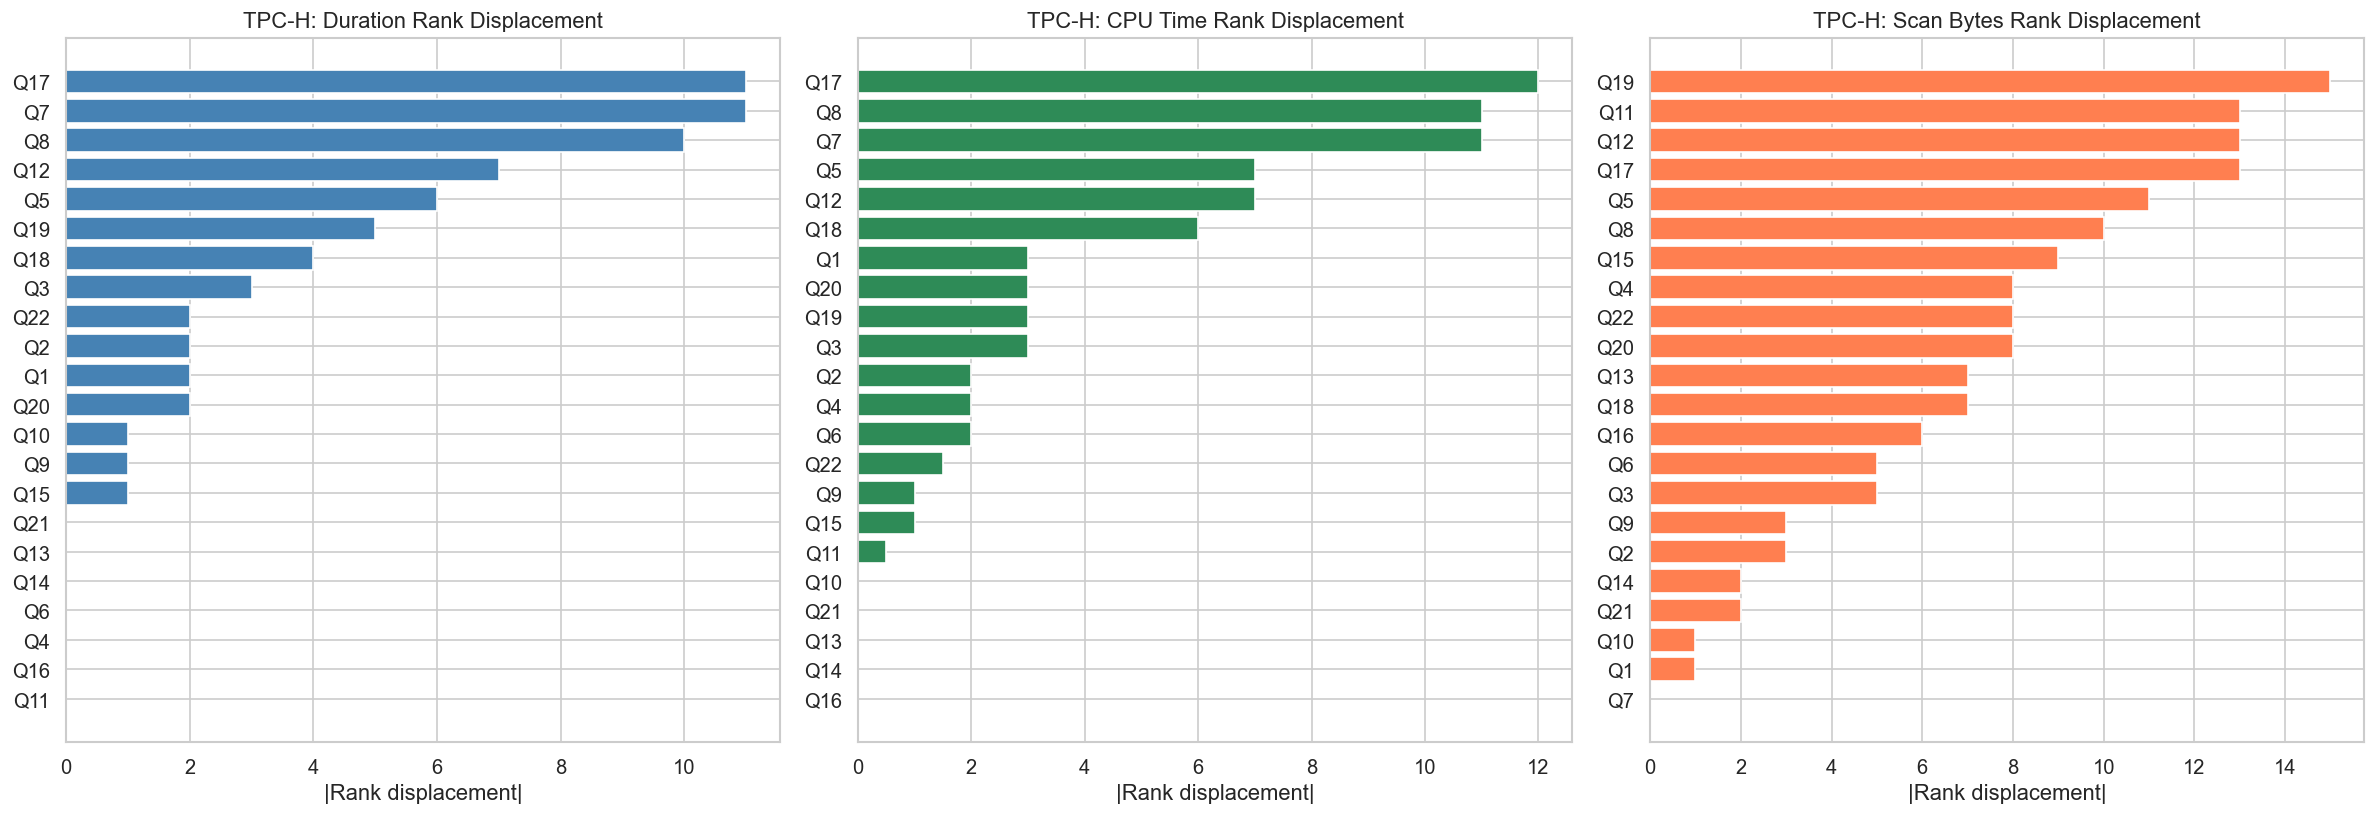

In [84]:
# TPC-H: rank displacement bar chart — all 3 metrics
tpch['dur_rank_disp'] = abs(tpch['db_duration_s_rank'] - tpch['fb_duration_s_rank'])
tpch['scan_rank_disp'] = abs(tpch['db_scan_bytes_rank'] - tpch['fb_scan_bytes_rank'])
tpch['cpu_rank_disp'] = abs(tpch['db_cpu_s_rank'] - tpch['fb_cpu_s_rank'])

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 7))

for ax, col, title, color in [
    (ax1, 'dur_rank_disp', 'Duration', 'steelblue'),
    (ax2, 'cpu_rank_disp', 'CPU Time', 'seagreen'),
    (ax3, 'scan_rank_disp', 'Scan Bytes', 'coral'),
]:
    order = tpch[col].sort_values(ascending=True).index
    ax.barh(range(len(order)), tpch.loc[order, col], color=color)
    ax.set_yticks(range(len(order))); ax.set_yticklabels(order)
    ax.set_xlabel('|Rank displacement|')
    ax.set_title(f'TPC-H: {title} Rank Displacement')

plt.tight_layout()
plt.show()

In [85]:
# Compute all ratios for both benchmarks
for df in [tpch, tpcds]:
    df['duration_ratio'] = np.maximum(df['db_duration_s'], df['fb_duration_s']) / (
        np.minimum(df['db_duration_s'], df['fb_duration_s']) + EPS)
    df['cpu_ratio'] = np.maximum(df['db_cpu_s'], df['fb_cpu_s']) / (
        np.minimum(df['db_cpu_s'], df['fb_cpu_s']) + EPS)
    df['scan_ratio'] = np.maximum(df['db_scan_bytes'], df['fb_scan_bytes']) / (
        np.minimum(df['db_scan_bytes'], df['fb_scan_bytes']) + EPS)
    df['slower_backend'] = np.where(
        df['db_duration_s'] > df['fb_duration_s'], 'Databend', 'Firebolt')
    df['more_cpu_backend'] = np.where(
        df['db_cpu_s'] > df['fb_cpu_s'], 'Databend', 'Firebolt')
    df['more_scan_backend'] = np.where(
        df['db_scan_bytes'] > df['fb_scan_bytes'], 'Databend', 'Firebolt')

# --- TPC-H: Top queries by DURATION ratio ---
print('TPC-H: All queries sorted by DURATION ratio')
display(tpch[['db_duration_s', 'fb_duration_s', 'duration_ratio', 'slower_backend',
              'dur_rank_disp']].sort_values('duration_ratio', ascending=False).head(15))

# --- TPC-H: Top queries by CPU TIME ratio ---
print('\nTPC-H: All queries sorted by CPU TIME ratio')
display(tpch[['db_cpu_s', 'fb_cpu_s', 'cpu_ratio', 'more_cpu_backend',
              'cpu_rank_disp']].sort_values('cpu_ratio', ascending=False).head(15))

# --- TPC-H: Top queries by SCAN BYTES ratio ---
print('\nTPC-H: All queries sorted by SCAN BYTES ratio')
display(tpch[['db_scan_bytes', 'fb_scan_bytes', 'scan_ratio', 'more_scan_backend',
              'scan_rank_disp']].sort_values('scan_ratio', ascending=False).head(15))

TPC-H: All queries sorted by DURATION ratio


,db_duration_s,fb_duration_s,duration_ratio,slower_backend,dur_rank_disp
query,,,,,
Q21,305.393305,6.430573,47.490835,Databend,0.0
Q3,35.267542,2.475815,14.244819,Databend,3.0
Q17,0.981994,3.811421,3.881308,Firebolt,11.0
Q7,1.078020,4.175206,3.873031,Firebolt,11.0
Q2,0.150143,0.531559,3.540359,Firebolt,2.0
Q8,3.053509,1.169414,2.611145,Databend,10.0
Q9,10.909962,5.633297,1.936692,Databend,1.0
Q12,2.596546,1.425186,1.821900,Databend,7.0
Q5,1.251725,2.251958,1.799083,Firebolt,6.0



TPC-H: All queries sorted by CPU TIME ratio


,db_cpu_s,fb_cpu_s,cpu_ratio,more_cpu_backend,cpu_rank_disp
query,,,,,
Q21,3900.0,49.949887,78.078255,Databend,0.0
Q3,477.0,17.648200,27.028252,Databend,3.0
Q8,35.0,8.432860,4.150431,Databend,11.0
Q9,139.0,40.907032,3.397949,Databend,1.0
Q17,9.0,29.895917,3.321769,Firebolt,12.0
Q2,1.0,3.141270,3.141270,Firebolt,2.0
Q1,51.0,16.721677,3.049933,Databend,3.0
Q7,11.0,31.319546,2.847231,Firebolt,11.0
Q12,29.0,10.874909,2.666689,Databend,7.0



TPC-H: All queries sorted by SCAN BYTES ratio


,db_scan_bytes,fb_scan_bytes,scan_ratio,more_scan_backend,scan_rank_disp
query,,,,,
Q17,6.958920e+06,3.990128e+09,573.383230,Firebolt,13.0
Q2,1.600208e+06,7.904234e+08,493.950383,Firebolt,3.0
Q12,3.148142e+07,4.156132e+09,132.018543,Firebolt,13.0
Q8,4.475196e+07,3.879847e+09,86.696689,Firebolt,10.0
Q6,4.861558e+07,3.359849e+09,69.110535,Firebolt,5.0
Q19,1.338580e+08,7.640151e+09,57.076534,Firebolt,15.0
Q3,8.499800e+07,3.425870e+09,40.305302,Firebolt,5.0
Q15,3.459237e+08,5.777532e+09,16.701752,Firebolt,9.0
Q14,2.002885e+08,3.014268e+09,15.049630,Firebolt,2.0


In [86]:
# TPC-DS: rank displacements including CPU
tpcds['dur_rank_disp'] = abs(tpcds['db_duration_s_rank'] - tpcds['fb_duration_s_rank'])
tpcds['scan_rank_disp'] = abs(tpcds['db_scan_bytes_rank'] - tpcds['fb_scan_bytes_rank'])
tpcds['cpu_rank_disp'] = abs(tpcds['db_cpu_s_rank'] - tpcds['fb_cpu_s_rank'])
tpcds['combined_disp'] = tpcds['dur_rank_disp'] + tpcds['scan_rank_disp'] + tpcds['cpu_rank_disp']

# --- TPC-DS: Top 15 by DURATION ratio ---
print('TPC-DS: Top 15 queries by DURATION ratio')
display(tpcds[['db_duration_s', 'fb_duration_s', 'duration_ratio', 'slower_backend',
               'dur_rank_disp']].sort_values('duration_ratio', ascending=False).head(15))

# --- TPC-DS: Top 15 by CPU TIME ratio ---
print('\nTPC-DS: Top 15 queries by CPU TIME ratio')
valid_cpu_tpcds = tpcds[(tpcds['db_cpu_s'] > 0) & (tpcds['fb_cpu_s'] > 0)]
display(valid_cpu_tpcds[['db_cpu_s', 'fb_cpu_s', 'cpu_ratio', 'more_cpu_backend',
                          'cpu_rank_disp']].sort_values('cpu_ratio', ascending=False).head(15))

# --- TPC-DS: Top 15 by SCAN BYTES ratio ---
print('\nTPC-DS: Top 15 queries by SCAN BYTES ratio')
display(tpcds[['db_scan_bytes', 'fb_scan_bytes', 'scan_ratio', 'more_scan_backend',
               'scan_rank_disp']].sort_values('scan_ratio', ascending=False).head(15))

# --- TPC-DS: Top 15 by combined rank displacement (all 3 metrics) ---
print(f'\nTPC-DS: Top 15 queries by combined rank displacement (duration + CPU + scan)')
display(tpcds.nlargest(15, 'combined_disp')[
    ['db_duration_s', 'fb_duration_s', 'db_cpu_s', 'fb_cpu_s',
     'db_scan_bytes', 'fb_scan_bytes',
     'dur_rank_disp', 'cpu_rank_disp', 'scan_rank_disp', 'combined_disp']
])

TPC-DS: Top 15 queries by DURATION ratio


,db_duration_s,fb_duration_s,duration_ratio,slower_backend,dur_rank_disp
query,,,,,
Q44,0.012826,1.552180,121.016293,Firebolt,52.0
Q10,0.007666,0.816949,106.569637,Firebolt,35.0
Q95,0.024936,2.255275,90.443556,Firebolt,67.0
Q94,0.021485,1.090902,50.775382,Firebolt,39.0
Q93,0.575118,0.017499,32.865835,Databend,27.0
Q26,0.020066,0.369618,18.419663,Firebolt,18.0
Q17,1.598153,15.586523,9.752833,Firebolt,23.0
Q31,0.116633,0.023222,5.022525,Databend,4.0
Q36,0.131782,0.029118,4.525739,Databend,4.0



TPC-DS: Top 15 queries by CPU TIME ratio


,db_cpu_s,fb_cpu_s,cpu_ratio,more_cpu_backend,cpu_rank_disp
query,,,,,
Q93,2.0,0.010009,199.820142,Databend,17.5
Q56,14.0,2.251414,6.218314,Databend,49.0
Q70,7.0,37.815025,5.402146,Firebolt,40.0
Q18,36.0,6.664069,5.402105,Databend,42.0
Q12,63.0,15.100462,4.172058,Databend,19.0
Q17,15.0,55.841935,3.722796,Firebolt,20.5
Q63,5.0,18.312818,3.662564,Firebolt,37.0
Q55,87.0,26.061083,3.338311,Databend,6.0
Q21,50.0,15.562594,3.212832,Databend,16.0



TPC-DS: Top 15 queries by SCAN BYTES ratio


,db_scan_bytes,fb_scan_bytes,scan_ratio,more_scan_backend,scan_rank_disp
query,,,,,
Q44,1.0,4.295054e+09,4.295054e+09,Firebolt,76.0
Q10,1.0,1.827732e+09,1.827732e+09,Firebolt,48.0
Q26,1.0,1.037923e+09,1.037923e+09,Firebolt,25.0
Q95,1.0,9.785430e+08,9.785430e+08,Firebolt,23.0
Q94,1.0,8.633740e+08,8.633740e+08,Firebolt,20.0
Q93,116540681.0,9.470000e+02,1.230630e+05,Databend,32.0
Q31,245.0,4.281292e+06,1.747466e+04,Firebolt,3.0
Q17,2117971.0,3.751786e+09,1.771406e+03,Firebolt,65.0
Q5,20740932.0,3.873497e+09,1.867562e+02,Firebolt,59.0



TPC-DS: Top 15 queries by combined rank displacement (duration + CPU + scan)


,db_duration_s,fb_duration_s,db_cpu_s,fb_cpu_s,db_scan_bytes,fb_scan_bytes,dur_rank_disp,cpu_rank_disp,scan_rank_disp,combined_disp
query,,,,,,,,,,
Q44,0.012826,1.552180,0.0,11.855679,1.000000e+00,4.295054e+09,52.0,48.0,76.0,176.0
Q95,0.024936,2.255275,0.0,16.731628,1.000000e+00,9.785430e+08,67.0,62.0,23.0,152.0
Q56,1.155856,0.328056,14.0,2.251414,7.127678e+08,8.134323e+08,38.0,49.0,35.0,122.0
Q10,0.007666,0.816949,0.0,5.612457,1.000000e+00,1.827732e+09,35.0,26.0,48.0,109.0
Q17,1.598153,15.586523,15.0,55.841935,2.117971e+06,3.751786e+09,23.0,20.5,65.0,108.5
Q18,3.626947,0.953678,36.0,6.664069,4.008131e+08,2.920126e+09,41.0,42.0,15.0,98.0
Q94,0.021485,1.090902,0.0,7.952352,1.000000e+00,8.633740e+08,39.0,35.0,20.0,94.0
Q21,4.325334,2.063779,50.0,15.562594,7.373094e+07,1.105899e+10,14.0,16.0,60.0,90.0
Q54,1.236281,0.657469,14.0,4.485987,2.448835e+09,1.822096e+09,27.0,35.0,23.0,85.0


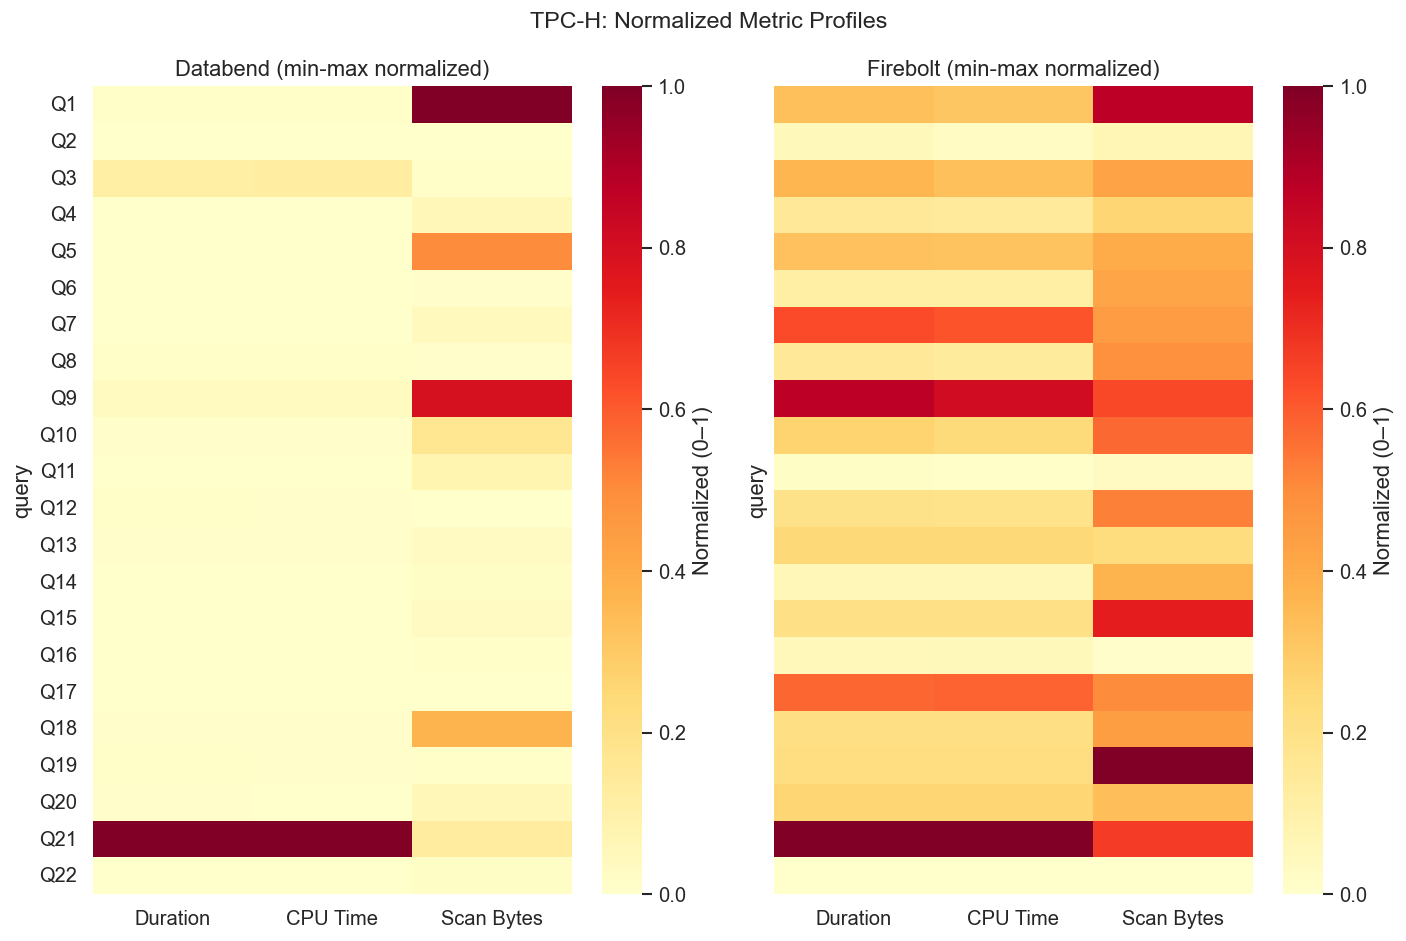

How to read this heatmap:
  Each row is a TPC-H query. Each column is a metric, min-max scaled to [0, 1]
  within that backend. Dark = low relative to other queries, bright = high.
  If both heatmaps show the same pattern (same rows light up), the backends
  agree on which queries are expensive. Differences reveal backend-specific
  behavior — e.g. a query that is bright in Databend CPU but dark in Firebolt
  means Databend spends disproportionately more CPU on that query.


In [87]:
# TPC-H: Normalized metric heatmap (side-by-side) — Duration, CPU Time, Scan Bytes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 8), sharey=True)

scaler = MinMaxScaler()

db_cols = ['db_duration_s', 'db_cpu_s', 'db_scan_bytes']
fb_cols = ['fb_duration_s', 'fb_cpu_s', 'fb_scan_bytes']
col_labels = ['Duration', 'CPU Time', 'Scan Bytes']

db_norm = pd.DataFrame(
    scaler.fit_transform(tpch[db_cols]),
    index=tpch.index, columns=col_labels)
fb_norm = pd.DataFrame(
    scaler.fit_transform(tpch[fb_cols]),
    index=tpch.index, columns=col_labels)

sns.heatmap(db_norm, ax=ax1, cmap='YlOrRd', annot=False, cbar_kws={'label': 'Normalized (0–1)'})
ax1.set_title('Databend (min-max normalized)')
sns.heatmap(fb_norm, ax=ax2, cmap='YlOrRd', annot=False, cbar_kws={'label': 'Normalized (0–1)'})
ax2.set_title('Firebolt (min-max normalized)')

fig.suptitle('TPC-H: Normalized Metric Profiles', fontsize=14)
plt.tight_layout()
plt.show()

print('How to read this heatmap:')
print('  Each row is a TPC-H query. Each column is a metric, min-max scaled to [0, 1]')
print('  within that backend. Dark = low relative to other queries, bright = high.')
print('  If both heatmaps show the same pattern (same rows light up), the backends')
print('  agree on which queries are expensive. Differences reveal backend-specific')
print('  behavior — e.g. a query that is bright in Databend CPU but dark in Firebolt')
print('  means Databend spends disproportionately more CPU on that query.')

---
## 3. Operator Flag Agreement

Binary operator flags (filter, join, agg, sort) come from plan inspection.
Semantically identical queries should have identical flags. Disagreement indicates
plan differences or collection failures.

In [88]:
def compare_operator_flags(df, label):
    ops = ['filter', 'join', 'agg', 'sort']
    agree, disagree, missing = 0, 0, 0
    disagree_details = []
    for idx, row in df.iterrows():
        for op in ops:
            db_val = row[f'db_{op}']
            fb_val = row[f'fb_{op}']
            if pd.isna(db_val) or pd.isna(fb_val):
                missing += 1
            elif db_val == fb_val:
                agree += 1
            else:
                disagree += 1
                disagree_details.append(f'  {idx} {op}: DB={int(db_val)} FB={int(fb_val)}')

    total = agree + disagree + missing
    print(f'\n{label}: {agree}/{total} agree, {disagree} disagree, {missing} missing')
    if disagree_details:
        print('Disagreements:')
        for d in disagree_details[:20]:
            print(d)

compare_operator_flags(tpch, f'TPC-H (n={len(tpch)})')
compare_operator_flags(tpcds, f'TPC-DS (n={len(tpcds)})')


TPC-H (n=22): 88/88 agree, 0 disagree, 0 missing

TPC-DS (n=88): 329/352 agree, 3 disagree, 20 missing
Disagreements:
  Q25 sort: DB=1 FB=0
  Q90 sort: DB=1 FB=0
  Q96 sort: DB=1 FB=0


---
## 4. RQ3: Could There Be 1:N Matching?

If semantically different queries produce nearly identical telemetry signatures,
a model trained on telemetry could confuse them. We build a feature vector per query
`[log10(duration), log10(scan_bytes), filter, join, agg, sort]`, standardize,
and find all query pairs closer than a threshold in Euclidean distance.

In [89]:
def build_telemetry_features(tpch_df, tpcds_df, prefix='db'):
    """Build a feature matrix from one backend's telemetry.
    Features: log10(duration), log10(scan_bytes), filter, join, agg, sort
    Skips queries with duration < 0.01 or scan_bytes < 1.
    """
    rows = []
    labels = []

    for idx, row in tpch_df.iterrows():
        dur = row[f'{prefix}_duration_s']
        scan = row[f'{prefix}_scan_bytes']
        if dur < 0.01 or scan < 1:
            continue
        rows.append({
            'log_duration': np.log10(dur),
            'log_scan_bytes': np.log10(scan),
            'filter': row[f'{prefix}_filter'] if not pd.isna(row[f'{prefix}_filter']) else 0,
            'join': row[f'{prefix}_join'] if not pd.isna(row[f'{prefix}_join']) else 0,
            'agg': row[f'{prefix}_agg'] if not pd.isna(row[f'{prefix}_agg']) else 0,
            'sort': row[f'{prefix}_sort'] if not pd.isna(row[f'{prefix}_sort']) else 0,
        })
        labels.append(f'H-{idx}')

    for idx, row in tpcds_df.iterrows():
        dur = row[f'{prefix}_duration_s']
        scan = row[f'{prefix}_scan_bytes']
        if dur < 0.01 or scan < 1:
            continue
        rows.append({
            'log_duration': np.log10(dur),
            'log_scan_bytes': np.log10(scan),
            'filter': row[f'{prefix}_filter'] if not pd.isna(row[f'{prefix}_filter']) else 0,
            'join': row[f'{prefix}_join'] if not pd.isna(row[f'{prefix}_join']) else 0,
            'agg': row[f'{prefix}_agg'] if not pd.isna(row[f'{prefix}_agg']) else 0,
            'sort': row[f'{prefix}_sort'] if not pd.isna(row[f'{prefix}_sort']) else 0,
        })
        labels.append(f'DS-{idx}')

    return pd.DataFrame(rows, index=labels)

db_features = build_telemetry_features(tpch, tpcds, prefix='db')
fb_features = build_telemetry_features(tpch, tpcds, prefix='fb')

print(f'Databend feature matrix: {db_features.shape}')
print(f'Firebolt feature matrix: {fb_features.shape}')
display(db_features.describe())

Databend feature matrix: (109, 6)
Firebolt feature matrix: (110, 6)


,log_duration,log_scan_bytes,filter,join,agg,sort
count,109.000000,109.000000,109.000000,109.000000,109.000000,109.000000
mean,-0.006583,8.099323,0.963303,0.944954,0.954128,0.862385
std,0.600966,1.913438,0.188886,0.229123,0.210173,0.346086
min,-1.891902,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-0.250404,7.738998,1.000000,1.000000,1.000000,1.000000
50%,0.001932,8.474017,1.000000,1.000000,1.000000,1.000000
75%,0.301933,9.148943,1.000000,1.000000,1.000000,1.000000
max,2.484860,10.080392,1.000000,1.000000,1.000000,1.000000


In [99]:
# Standardize and compute distance matrices (Databend & Firebolt)
scaler_db = StandardScaler()
db_scaled = scaler_db.fit_transform(db_features)

db_dist_vec = pdist(db_scaled, metric='euclidean')
db_dist_matrix = squareform(db_dist_vec)
db_dist_df = pd.DataFrame(db_dist_matrix, index=db_features.index, columns=db_features.index)

print('--- Databend ---')
print(f'Distance matrix: {db_dist_df.shape}')
nonzero = db_dist_matrix[db_dist_matrix > 0]
print(f'Min distance: {nonzero.min():.3f}')
print(f'Median distance: {np.median(nonzero):.3f}')
print(f'Max distance: {nonzero.max():.3f}')

scaler_fb = StandardScaler()
fb_scaled = scaler_fb.fit_transform(fb_features)

fb_dist_vec = pdist(fb_scaled, metric='euclidean')
fb_dist_matrix = squareform(fb_dist_vec)
fb_dist_df = pd.DataFrame(fb_dist_matrix, index=fb_features.index, columns=fb_features.index)

print('\n--- Firebolt ---')
print(f'Distance matrix: {fb_dist_df.shape}')
nonzero_fb = fb_dist_matrix[fb_dist_matrix > 0]
print(f'Min distance: {nonzero_fb.min():.3f}')
print(f'Median distance: {np.median(nonzero_fb):.3f}')
print(f'Max distance: {nonzero_fb.max():.3f}')

--- Databend ---
Distance matrix: (109, 109)
Min distance: 0.017
Median distance: 1.316
Max distance: 12.466

--- Firebolt ---
Distance matrix: (110, 110)
Min distance: 0.004
Median distance: 1.673
Max distance: 13.489


In [100]:
# All collision pairs (distance < threshold) — intra-backend only
COLLISION_THRESHOLD = 1.0
OPS = ['filter', 'join', 'agg', 'sort']

# --- Databend collisions ---
def get_cpu_db(label):
    if label.startswith('H-'):
        q = label.replace('H-', '')
        return tpch.loc[q, 'db_cpu_s'] if q in tpch.index else 0
    else:
        q = label.replace('DS-', '')
        return tpcds.loc[q, 'db_cpu_s'] if q in tpcds.index else 0

db_collisions = []
for i, li in enumerate(db_features.index):
    for j, lj in enumerate(db_features.index):
        if j <= i:
            continue
        d = db_dist_matrix[i, j]
        if d < COLLISION_THRESHOLD:
            row = {
                'query_a': li, 'query_b': lj, 'distance': round(d, 3),
                'dur_a': round(10**db_features.loc[li, 'log_duration'], 3),
                'dur_b': round(10**db_features.loc[lj, 'log_duration'], 3),
                'cpu_a': round(get_cpu_db(li), 1),
                'cpu_b': round(get_cpu_db(lj), 1),
                'scan_GB_a': round(10**db_features.loc[li, 'log_scan_bytes'] / 1e9, 2),
                'scan_GB_b': round(10**db_features.loc[lj, 'log_scan_bytes'] / 1e9, 2),
            }
            for op in OPS:
                row[f'{op}_a'] = int(db_features.loc[li, op])
                row[f'{op}_b'] = int(db_features.loc[lj, op])
            db_collisions.append(row)

collision_df = pd.DataFrame(db_collisions).sort_values('distance')
n_db_pairs = len(db_features) * (len(db_features) - 1) // 2

# --- Firebolt collisions ---
def get_cpu_fb(label):
    if label.startswith('H-'):
        q = label.replace('H-', '')
        return tpch.loc[q, 'fb_cpu_s'] if q in tpch.index else 0
    else:
        q = label.replace('DS-', '')
        return tpcds.loc[q, 'fb_cpu_s'] if q in tpcds.index else 0

fb_collisions = []
for i, li in enumerate(fb_features.index):
    for j, lj in enumerate(fb_features.index):
        if j <= i:
            continue
        d = fb_dist_matrix[i, j]
        if d < COLLISION_THRESHOLD:
            row = {
                'query_a': li, 'query_b': lj, 'distance': round(d, 3),
                'dur_a': round(10**fb_features.loc[li, 'log_duration'], 3),
                'dur_b': round(10**fb_features.loc[lj, 'log_duration'], 3),
                'cpu_a': round(get_cpu_fb(li), 1),
                'cpu_b': round(get_cpu_fb(lj), 1),
                'scan_GB_a': round(10**fb_features.loc[li, 'log_scan_bytes'] / 1e9, 2),
                'scan_GB_b': round(10**fb_features.loc[lj, 'log_scan_bytes'] / 1e9, 2),
            }
            for op in OPS:
                row[f'{op}_a'] = int(fb_features.loc[li, op])
                row[f'{op}_b'] = int(fb_features.loc[lj, op])
            fb_collisions.append(row)

fb_collision_df = pd.DataFrame(fb_collisions).sort_values('distance')
n_fb_pairs = len(fb_features) * (len(fb_features) - 1) // 2

# --- Summary stats ---
def collision_breakdown(cdf, label, n_pairs):
    print(f'--- {label} ---')
    print(f'Total query pairs: {n_pairs}')
    print(f'Collision pairs (distance < {COLLISION_THRESHOLD}): {len(cdf)} '
          f'({100*len(cdf)/n_pairs:.1f}%)')
    if len(cdf) > 0:
        cross = cdf[cdf.apply(lambda r: r['query_a'][:2] != r['query_b'][:2], axis=1)]
        within_h = cdf[cdf.apply(lambda r: r['query_a'].startswith('H-') and r['query_b'].startswith('H-'), axis=1)]
        within_ds = cdf[cdf.apply(lambda r: r['query_a'].startswith('DS-') and r['query_b'].startswith('DS-'), axis=1)]
        print(f'  Cross-benchmark (TPC-H <-> TPC-DS): {len(cross)}')
        print(f'  Within TPC-H: {len(within_h)}')
        print(f'  Within TPC-DS: {len(within_ds)}')

collision_breakdown(collision_df, 'Databend', n_db_pairs)
print()
collision_breakdown(fb_collision_df, 'Firebolt', n_fb_pairs)

# --- Top 25 side by side ---
print(f'\nTop 25 closest collision pairs (Databend):')
display(collision_df.head(25))

print(f'\nTop 25 closest collision pairs (Firebolt):')
display(fb_collision_df.head(25))

--- Databend ---
Total query pairs: 5886
Collision pairs (distance < 1.0): 2257 (38.3%)
  Cross-benchmark (TPC-H <-> TPC-DS): 613
  Within TPC-H: 55
  Within TPC-DS: 1589

--- Firebolt ---
Total query pairs: 5995
Collision pairs (distance < 1.0): 1886 (31.5%)
  Cross-benchmark (TPC-H <-> TPC-DS): 611
  Within TPC-H: 70
  Within TPC-DS: 1205

Top 25 closest collision pairs (Databend):


,query_a,query_b,distance,dur_a,dur_b,cpu_a,cpu_b,scan_GB_a,scan_GB_b,filter_a,filter_b,join_a,join_b,agg_a,agg_b,sort_a,sort_b
1938,DS-Q56,DS-Q65,0.017,1.156,1.131,14.0,9.0,0.71,0.69,1,1,1,1,1,1,1,1
249,H-Q10,DS-Q47,0.023,2.004,1.946,21.0,23.0,1.81,1.75,1,1,1,1,1,1,1,1
899,DS-Q7,DS-Q82,0.030,0.347,0.334,0.0,1.0,0.14,0.13,1,1,1,1,1,1,1,1
1788,DS-Q49,DS-Q60,0.034,0.562,0.570,7.0,6.0,0.01,0.01,1,1,1,1,1,1,1,1
462,H-Q16,DS-Q2,0.034,0.580,0.605,4.0,3.0,0.16,0.18,1,1,1,1,1,1,1,1
1448,DS-Q30,DS-Q68,0.039,1.337,1.279,17.0,17.0,2.56,2.81,1,1,1,1,1,1,1,1
1911,DS-Q54,DS-Q68,0.040,1.236,1.279,14.0,17.0,2.45,2.81,1,1,1,1,1,1,1,1
1155,DS-Q19,DS-Q88,0.041,0.731,0.691,4.0,8.0,0.03,0.03,1,1,1,1,1,1,1,1
1628,DS-Q40,DS-Q85,0.042,0.318,0.311,2.0,3.0,0.42,0.35,1,1,1,1,1,1,1,1
31,H-Q4,DS-Q27,0.046,0.922,0.902,7.0,8.0,0.64,0.77,1,1,1,1,1,1,1,1



Top 25 closest collision pairs (Firebolt):


,query_a,query_b,distance,dur_a,dur_b,cpu_a,cpu_b,scan_GB_a,scan_GB_b,filter_a,filter_b,join_a,join_b,agg_a,agg_b,sort_a,sort_b
1336,DS-Q37,DS-Q48,0.004,0.356,0.357,2.6,2.7,1.04,1.04,1,1,1,1,1,1,1,1
1796,DS-Q67,DS-Q77,0.014,1.430,1.426,11.1,11.0,3.03,2.95,1,1,1,1,1,1,1,1
1604,DS-Q51,DS-Q66,0.014,0.349,0.347,2.6,2.3,1.04,1.01,1,1,1,1,1,1,1,1
1572,DS-Q49,DS-Q60,0.015,0.786,0.772,6.0,5.9,1.33,1.33,1,1,1,1,1,1,1,1
1339,DS-Q37,DS-Q51,0.017,0.356,0.349,2.6,2.6,1.04,1.04,1,1,1,1,1,1,1,1
1553,DS-Q48,DS-Q51,0.021,0.357,0.349,2.7,2.6,1.04,1.04,1,1,1,1,1,1,1,1
1344,DS-Q37,DS-Q66,0.026,0.356,0.347,2.6,2.3,1.04,1.01,1,1,1,1,1,1,1,1
1858,DS-Q76,DS-Q79,0.028,2.658,2.598,19.8,19.9,4.66,4.84,1,1,1,1,1,1,1,1
1558,DS-Q48,DS-Q66,0.029,0.357,0.347,2.7,2.3,1.04,1.01,1,1,1,1,1,1,1,1
167,H-Q5,DS-Q45,0.031,2.252,2.182,17.2,17.0,3.27,3.36,1,1,1,1,1,1,1,1


In [92]:
# Backend stability: do Databend and Firebolt produce the same clusters?
common = db_features.index.intersection(fb_features.index)
db_common = db_features.loc[common]
fb_common = fb_features.loc[common]

N_CLUSTERS = 8

db_scaled_common = StandardScaler().fit_transform(db_common)
db_link = linkage(pdist(db_scaled_common), method='ward')
db_clusters = fcluster(db_link, N_CLUSTERS, criterion='maxclust')

fb_scaled_common = StandardScaler().fit_transform(fb_common)
fb_link = linkage(pdist(fb_scaled_common), method='ward')
fb_clusters = fcluster(fb_link, N_CLUSTERS, criterion='maxclust')

ari = adjusted_rand_score(db_clusters, fb_clusters)
print(f'Adjusted Rand Index (Databend vs Firebolt clusters, k={N_CLUSTERS}): {ari:.3f}')
print(f'  1.0 = identical clustering, 0.0 = random agreement')
print(f'  Queries compared: {len(common)}')
print(f'\nInterpretation: ARI={ari:.2f} means the collision structure is only partially')
print(f'stable across backends — which queries look "similar" depends on the engine.')

Adjusted Rand Index (Databend vs Firebolt clusters, k=8): 0.301
  1.0 = identical clustering, 0.0 = random agreement
  Queries compared: 109

Interpretation: ARI=0.30 means the collision structure is only partially
stable across backends — which queries look "similar" depends on the engine.


---
## 5. Metric Decoupling: Scan Bytes vs Duration vs CPU Time

Are scan bytes, duration, and CPU time correlated? Or do some queries scan a lot but finish fast
(good predicate pushdown / caching) while others scan little but run long (expensive joins)?
High correlation means the metrics are redundant; low correlation means each adds independent signal.

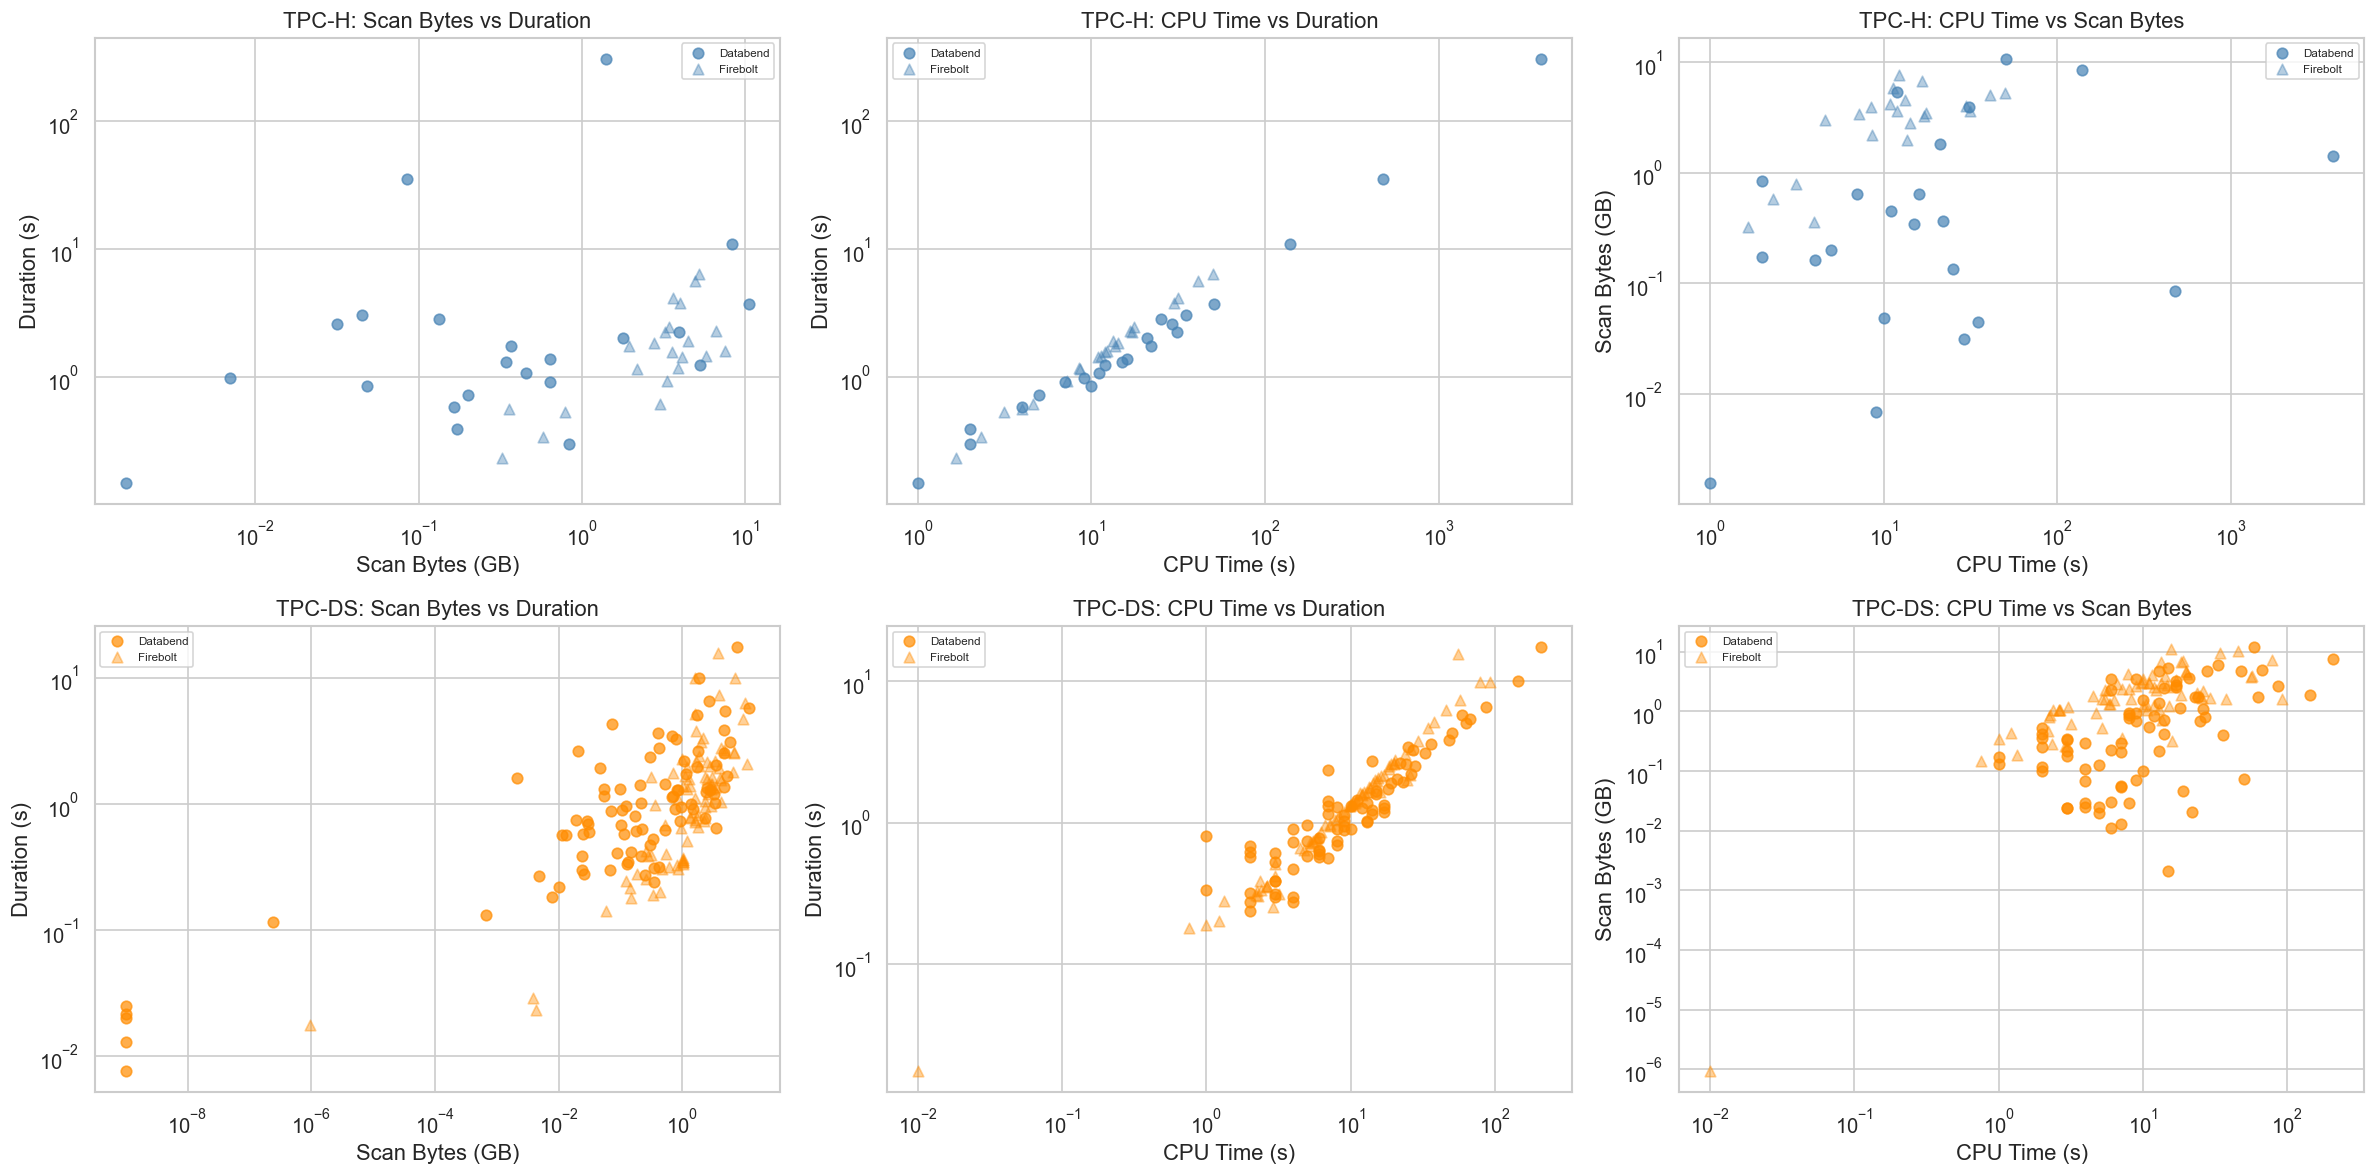

Pearson r on log10-transformed values:
                       Scan↔Duration    CPU↔Duration        CPU↔Scan
  TPC-H Databend                 0.343           0.993           0.362
  TPC-H Firebolt                 0.767           0.998           0.779
  TPC-DS Databend                0.496           0.920           0.510
  TPC-DS Firebolt                0.772           0.973           0.845


In [93]:
# Pairwise metric scatter: scan vs duration, CPU vs duration, CPU vs scan
# Each row = one benchmark (TPC-H, TPC-DS), each column = one metric pair
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
pairs = [
    ('scan_bytes', 'duration_s', 'Scan Bytes (GB)', 'Duration (s)', lambda x: x / 1e9, lambda y: y),
    ('cpu_s', 'duration_s', 'CPU Time (s)', 'Duration (s)', lambda x: x, lambda y: y),
    ('cpu_s', 'scan_bytes', 'CPU Time (s)', 'Scan Bytes (GB)', lambda x: x, lambda y: y / 1e9),
]

for col, (mx, my, xlabel, ylabel, xfn, yfn) in enumerate(pairs):
    for row, (df, label, color) in enumerate([
        (tpch, 'TPC-H', 'steelblue'),
        (tpcds, 'TPC-DS', 'darkorange'),
    ]):
        ax = axes[row, col]
        valid = df[(df[f'db_{mx}'] > 0) & (df[f'db_{my}'] > 0) &
                   (df[f'fb_{mx}'] > 0) & (df[f'fb_{my}'] > 0)]
        ax.scatter(xfn(valid[f'db_{mx}']), yfn(valid[f'db_{my}']),
                  c=color, s=40, alpha=0.7, label='Databend', zorder=3)
        ax.scatter(xfn(valid[f'fb_{mx}']), yfn(valid[f'fb_{my}']),
                  c=color, s=40, alpha=0.4, marker='^', label='Firebolt', zorder=3)
        ax.set_xscale('log'); ax.set_yscale('log')
        ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
        ax.set_title(f'{label}: {xlabel.split("(")[0].strip()} vs {ylabel.split("(")[0].strip()}')
        ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

# Pearson r on log-transformed values — all 3 metric pairs
print('Pearson r on log10-transformed values:')
print(f'{"":20s} {"Scan↔Duration":>15s} {"CPU↔Duration":>15s} {"CPU↔Scan":>15s}')
for label, df, prefix in [('TPC-H Databend', tpch, 'db'), ('TPC-H Firebolt', tpch, 'fb'),
                           ('TPC-DS Databend', tpcds, 'db'), ('TPC-DS Firebolt', tpcds, 'fb')]:
    valid = df[(df[f'{prefix}_scan_bytes'] > 0) & (df[f'{prefix}_duration_s'] > 0) &
               (df[f'{prefix}_cpu_s'] > 0)]
    log_scan = np.log10(valid[f'{prefix}_scan_bytes'])
    log_dur = np.log10(valid[f'{prefix}_duration_s'])
    log_cpu = np.log10(valid[f'{prefix}_cpu_s'])
    r_sd, _ = stats.pearsonr(log_scan, log_dur)
    r_cd, _ = stats.pearsonr(log_cpu, log_dur)
    r_cs, _ = stats.pearsonr(log_cpu, log_scan)
    print(f'  {label:20s} {r_sd:>15.3f} {r_cd:>15.3f} {r_cs:>15.3f}')

---
## 6. Structural Telemetry Collisions

The distance-based collision analysis above uses only the telemetry feature
vector (duration, scan bytes, operator flags).  Here we bring in the **full
structural fingerprint** from `telemetry_collision_analysis.py` — number of
tables, joins, subqueries, aggregations, predicates, CTEs, window functions,
etc. — and ask:

1. Which query pairs have very similar telemetry but very different structure?
2. Do these collisions persist when we require the structural signature to match?

In [ ]:
import sys, re
from itertools import combinations
sys.path.insert(0, str(Path('.').resolve()))
from telemetry_collision_analysis import (
    extract_structure, classify_query_type, QueryStructure,
    telemetry_distance, structural_distance,
)

In [ ]:
def build_query_structures(metrics_list, workload_name):
    """Build QueryStructure objects from a raw metrics JSON list."""
    qs_list = []
    for qi, entry in enumerate(metrics_list):
        sql = entry['query']
        if '@' in sql:
            sql = sql[:sql.rfind('@')]
        sql = sql.strip()
        feat = extract_structure(sql)
        qs = QueryStructure(
            query_text=sql,
            source=f'{workload_name}-Q{qi+1}',
            avg_cpu_time=entry.get('avg_cpu_time', 0),
            avg_scan_bytes=entry.get('avg_scan_bytes', 0),
            avg_duration=entry.get('avg_duration', 0),
            has_filter=bool(entry.get('filter', 0)),
            has_join=bool(entry.get('join', 0)),
            has_agg=bool(entry.get('agg', 0)),
            has_sort=bool(entry.get('sort', 0)),
            **{k: v for k, v in feat.items()},
        )
        qs.query_type = classify_query_type(qs)
        qs_list.append(qs)
    return qs_list

db_qs = build_query_structures(tpch_db, 'TPCH') + build_query_structures(tpcds_db, 'TPCDS')
fb_qs = build_query_structures(tpch_fb, 'TPCH') + build_query_structures(tpcds_fb, 'TPCDS')

print(f'Databend: {len(db_qs)} queries  |  Firebolt: {len(fb_qs)} queries')

### 6a. Top-15 telemetry collisions — Databend and Firebolt

Pairs with the **lowest telemetry distance** but **highest structural distance**.
These are structurally different queries that a telemetry-based approach
would treat as interchangeable.

In [ ]:
def find_top_collisions(qs_list, top_n=15,
                        tel_thresh=0.35, struct_thresh=5.0):
    """Find pairs with low telemetry distance but high structural distance."""
    hits = []
    for a, b in combinations(qs_list, 2):
        t = telemetry_distance(a, b)
        if t > tel_thresh:
            continue
        s = structural_distance(a, b)
        if s < struct_thresh:
            continue
        hits.append((a, b, t, s, s / max(t, 0.001)))
    hits.sort(key=lambda x: x[4], reverse=True)
    return hits[:top_n]


def collisions_to_df(hits):
    rows = []
    for a, b, t, s, ratio in hits:
        rows.append({
            'Query A': a.source, 'Query B': b.source,
            'Tel.Dist': t, 'Struct.Dist': s, 'Ratio': ratio,
            'A tables': a.num_tables, 'A joins': a.num_joins,
            'A subq': a.num_subqueries, 'A aggs': a.num_aggregations,
            'A type': a.query_type,
            'B tables': b.num_tables, 'B joins': b.num_joins,
            'B subq': b.num_subqueries, 'B aggs': b.num_aggregations,
            'B type': b.query_type,
        })
    return pd.DataFrame(rows)


# --- Databend ---
db_hits = find_top_collisions(db_qs)
if not db_hits:
    db_hits = find_top_collisions(db_qs, tel_thresh=0.50, struct_thresh=3.0)
db_coll = collisions_to_df(db_hits)

print(f'=== Databend: Top-{len(db_coll)} Telemetry Collisions ===')
display(db_coll.style.format({
    'Tel.Dist': '{:.3f}', 'Struct.Dist': '{:.1f}', 'Ratio': '{:.0f}'
}).background_gradient(subset=['Ratio'], cmap='Reds'))

In [ ]:
# --- Firebolt ---
fb_hits = find_top_collisions(fb_qs)
if not fb_hits:
    fb_hits = find_top_collisions(fb_qs, tel_thresh=0.50, struct_thresh=3.0)
fb_coll = collisions_to_df(fb_hits)

print(f'=== Firebolt: Top-{len(fb_coll)} Telemetry Collisions ===')
display(fb_coll.style.format({
    'Tel.Dist': '{:.3f}', 'Struct.Dist': '{:.1f}', 'Ratio': '{:.0f}'
}).background_gradient(subset=['Ratio'], cmap='Reds'))

### 6b. Collisions with matching structural signature

Now we **require** both queries in a pair to share the same structural
signature (same num_tables, num_joins, num_subqueries, same boolean
features).  Only telemetry distance is used to rank — these are
queries that look the same *both* structurally and in telemetry,
yet are actually different SQL.

In [ ]:
def find_same_structure_collisions(qs_list, top_n=15, tel_thresh=0.40):
    """Pairs with matching structural signature but different queries."""
    hits = []
    for a, b in combinations(qs_list, 2):
        # Must have the same structural signature
        if a.structural_signature != b.structural_signature:
            continue
        # Must be different queries (different source or different SQL)
        if a.source == b.source:
            continue
        t = telemetry_distance(a, b)
        if t > tel_thresh:
            continue
        hits.append((a, b, t))
    hits.sort(key=lambda x: x[2])
    return hits[:top_n]


def same_struct_to_df(hits):
    rows = []
    for a, b, t in hits:
        rows.append({
            'Query A': a.source, 'Query B': b.source,
            'Tel.Dist': t,
            'tables': a.num_tables, 'joins': a.num_joins,
            'subq': a.num_subqueries, 'aggs': a.num_aggregations,
            'preds': a.num_predicates,
            'struct_type': a.query_type,
            'A CPU(ms)': a.avg_cpu_time, 'B CPU(ms)': b.avg_cpu_time,
            'A Scan(MB)': a.avg_scan_bytes / 1e6,
            'B Scan(MB)': b.avg_scan_bytes / 1e6,
            'A Dur(s)': a.avg_duration, 'B Dur(s)': b.avg_duration,
        })
    return pd.DataFrame(rows)


# --- Databend: same structure ---
db_same = find_same_structure_collisions(db_qs)
if not db_same:
    db_same = find_same_structure_collisions(db_qs, tel_thresh=0.60)
db_same_df = same_struct_to_df(db_same)

print(f'=== Databend: Top-{len(db_same_df)} Collisions WITH Matching Structure ===')
if len(db_same_df) > 0:
    display(db_same_df.style.format({
        'Tel.Dist': '{:.3f}',
        'A CPU(ms)': '{:.1f}', 'B CPU(ms)': '{:.1f}',
        'A Scan(MB)': '{:.0f}', 'B Scan(MB)': '{:.0f}',
        'A Dur(s)': '{:.3f}', 'B Dur(s)': '{:.3f}',
    }).background_gradient(subset=['Tel.Dist'], cmap='Greens_r'))
else:
    print('No collisions found — no pairs share both structural signature and close telemetry.')

In [ ]:
# --- Firebolt: same structure ---
fb_same = find_same_structure_collisions(fb_qs)
if not fb_same:
    fb_same = find_same_structure_collisions(fb_qs, tel_thresh=0.60)
fb_same_df = same_struct_to_df(fb_same)

print(f'=== Firebolt: Top-{len(fb_same_df)} Collisions WITH Matching Structure ===')
if len(fb_same_df) > 0:
    display(fb_same_df.style.format({
        'Tel.Dist': '{:.3f}',
        'A CPU(ms)': '{:.1f}', 'B CPU(ms)': '{:.1f}',
        'A Scan(MB)': '{:.0f}', 'B Scan(MB)': '{:.0f}',
        'A Dur(s)': '{:.3f}', 'B Dur(s)': '{:.3f}',
    }).background_gradient(subset=['Tel.Dist'], cmap='Greens_r'))
else:
    print('No collisions found — no pairs share both structural signature and close telemetry.')